In [1]:
# ────────────────────────────────────────────────────────────
# CELL 1 — Install Dependencies
# ─────────────────────────────────────────────────────────────
!pip install kagglehub ultralytics timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.9 MB/s eta 0:00:00


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Imports & Reproducibility
# ─────────────────────────────────────────────────────────────
import os, cv2, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import kagglehub
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NW     = 4 if torch.cuda.is_available() else 0   # DataLoader workers
print(f"✅  Device : {DEVICE}  |  Workers : {NW}")

✅  Device : cuda  |  Workers : 4


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Download Datasets
# ─────────────────────────────────────────────────────────────
print("📥  Downloading Celeb-DF v2 ...")
celeb_path = kagglehub.dataset_download("reubensuju/celeb-df-v2")
print(f"    → {celeb_path}")

print("📥  Downloading FaceForensics++ (c23) ...")
ff_path = kagglehub.dataset_download("xdxd003/ff-c23")
print(f"    → {ff_path}")


📥  Downloading Celeb-DF v2 ...


100%|██████████| 9.29G/9.29G [09:46<00:00, 17.0MB/s]

Extracting files...


    → /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1
📥  Downloading FaceForensics++ (c23) ...
Using Colab cache for faster access to the 'ff-c23' dataset.
    → /kaggle/input/ff-c23


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Inspect Folder Structure
# ─────────────────────────────────────────────────────────────
def show_tree(root, depth=0, max_depth=3, max_files=4):
    if depth > max_depth or not Path(root).is_dir():
        return
    for item in sorted(Path(root).iterdir()):
        prefix = "  " * depth
        if item.is_dir():
            print(f"{prefix}📁 {item.name}/")
            show_tree(item, depth+1, max_depth, max_files)
        else:
            print(f"{prefix}📄 {item.name}")

print("\n── Celeb-DF ──"); show_tree(celeb_path)
print("\n── FF++ ──");     show_tree(ff_path)

Streaming output truncated to the last 5000 lines.
    📄 015_919.mp4
    📄 016_209.mp4
    📄 017_803.mp4
    📄 018_019.mp4
    📄 019_018.mp4
    📄 020_344.mp4
    📄 021_312.mp4
    📄 022_489.mp4
    📄 023_923.mp4
    📄 024_073.mp4
    📄 025_067.mp4
    📄 026_012.mp4
    📄 027_009.mp4
    📄 028_068.mp4
    📄 029_048.mp4
    📄 030_193.mp4
    📄 031_163.mp4
    📄 032_944.mp4
    📄 033_097.mp4
    📄 034_590.mp4
    📄 035_036.mp4
    📄 036_035.mp4
    📄 037_072.mp4
    📄 038_125.mp4
    📄 039_058.mp4
    📄 040_997.mp4
    📄 041_063.mp4
    📄 042_084.mp4
    📄 043_110.mp4
    📄 044_945.mp4
    📄 045_889.mp4
    📄 046_904.mp4
    📄 047_862.mp4
    📄 048_029.mp4
    📄 049_946.mp4
    📄 050_059.mp4
    📄 051_332.mp4
    📄 052_108.mp4
    📄 053_095.mp4
    📄 054_071.mp4
    📄 055_147.mp4
    📄 056_996.mp4
    📄 057_070.mp4
    📄 058_039.mp4
    📄 059_050.mp4
    📄 060_088.mp4
    📄 061_080.mp4
    📄 062_066.mp4
    📄 063_041.mp4
    📄 064_991.mp4
    📄 065_089.mp4
    📄 066_062.mp4
    📄 067_025

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Global Config
# ─────────────────────────────────────────────────────────────
CFG = {
    # Dataset source dirs (videos OR image folders)
    "celeb_real_dir"   : os.path.join(celeb_path, "Celeb-real"),
    "celeb_fake_dir"   : os.path.join(celeb_path, "Celeb-synthesis"),
    "ff_real_dir"      : os.path.join(ff_path, "original_sequences", "youtube", "c23", "videos"),
    "ff_fake_dir"      : os.path.join(ff_path, "manipulated_sequences", "Deepfakes", "c23", "videos"),

    # Where extracted frames are saved
    "frame_out"        : "/content/frames",

    # Sampling (keep small for speed)
    "frames_per_video" : 5,
    "max_videos"       : 40,    # per class per dataset  → ~400 frames/class total
    "img_size"         : 224,

    # Training
    "batch_size"       : 64,
    "epochs"           : 25,
    "lr"               : 1e-4,
    "patience"         : 5,
    "val_split"        : 0.15,
    "test_split"       : 0.15,

    # GAN
    "gan_epochs"       : 15,
    "gan_latent_dim"   : 100,
    "gan_gen_images"   : 100,
}

os.makedirs(CFG["frame_out"] + "/real", exist_ok=True)
os.makedirs(CFG["frame_out"] + "/fake", exist_ok=True)
print("✅  Config ready.")

✅  Config ready.


In [6]:

# ─────────────────────────────────────────────────────────────
# CELL 6 — Frame Extraction Helpers
# ─────────────────────────────────────────────────────────────
def extract_frames(video_path, out_dir, n_frames, img_size):
    """Extract n evenly-spaced frames from a video and save as JPEGs."""
    cap   = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release(); return []

    indices = np.linspace(0, max(total-1, 0), n_frames, dtype=int)
    stem    = Path(video_path).stem
    saved   = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.resize(frame, (img_size, img_size))
        fname = os.path.join(out_dir, f"{stem}_f{idx:05d}.jpg")
        cv2.imwrite(fname, frame)
        saved.append(fname)
    cap.release()
    return saved


def extract_from_images(src_dir, out_dir, img_size, max_imgs):
    """Resize and copy images from a flat/nested folder."""
    exts  = {".jpg", ".jpeg", ".png", ".bmp"}
    paths = [p for p in Path(src_dir).rglob("*") if p.suffix.lower() in exts][:max_imgs]
    saved = []
    for p in tqdm(paths, desc=f"  images {Path(src_dir).name}", leave=False):
        img = cv2.imread(str(p))
        if img is None: continue
        img = cv2.resize(img, (img_size, img_size))
        dst = os.path.join(out_dir, p.name)
        cv2.imwrite(dst, img)
        saved.append(dst)
    return saved


def process_dir(src_dir, out_dir, label, cfg):
    """Auto-detect videos or images, extract frames into out_dir."""
    src = Path(src_dir)
    if not src.exists():
        print(f"  ⚠️  Not found: {src_dir}"); return []

    vid_exts = {".mp4", ".avi", ".mov", ".mkv"}
    img_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    videos   = [p for p in src.rglob("*") if p.suffix.lower() in vid_exts]
    images   = [p for p in src.rglob("*") if p.suffix.lower() in img_exts]

    if videos:
        videos = videos[:cfg["max_videos"]]
        print(f"  🎥 [{label}] {len(videos)} videos")
        saved = []
        for v in tqdm(videos, desc=f"  [{label}]"):
            saved += extract_frames(v, out_dir, cfg["frames_per_video"], cfg["img_size"])
        return saved
    elif images:
        max_imgs = cfg["max_videos"] * cfg["frames_per_video"]
        print(f"  🖼️  [{label}] {len(images)} images (capped {max_imgs})")
        return extract_from_images(src_dir, out_dir, cfg["img_size"], max_imgs)
    else:
        print(f"  ⚠️  No media in {src_dir}"); return []

In [7]:

# ─────────────────────────────────────────────────────────────
# CELL 7 — Run Extraction
# ─────────────────────────────────────────────────────────────
real_out = CFG["frame_out"] + "/real"
fake_out = CFG["frame_out"] + "/fake"

print("── Celeb-DF ──")
process_dir(CFG["celeb_real_dir"], real_out, "Celeb-Real", CFG)
process_dir(CFG["celeb_fake_dir"], fake_out, "Celeb-Fake", CFG)

print("── FF++ ──")
process_dir(CFG["ff_real_dir"], real_out, "FF-Real", CFG)
process_dir(CFG["ff_fake_dir"], fake_out, "FF-Fake", CFG)

n_real = len(list(Path(real_out).glob("*.jpg")))
n_fake = len(list(Path(fake_out).glob("*.jpg")))
print(f"\n✅  Frames extracted → Real: {n_real}  Fake: {n_fake}")

if n_real == 0 or n_fake == 0:
    raise RuntimeError("❌ No frames found! Fix the paths in CFG (CELL 5) and re-run.")


── Celeb-DF ──
  🎥 [Celeb-Real] 40 videos


  [Celeb-Real]: 100%|██████████| 40/40 [00:03<00:00, 11.62it/s]


  🎥 [Celeb-Fake] 40 videos


  [Celeb-Fake]: 100%|██████████| 40/40 [00:02<00:00, 16.26it/s]

── FF++ ──
  ⚠️  Not found: /kaggle/input/ff-c23/original_sequences/youtube/c23/videos
  ⚠️  Not found: /kaggle/input/ff-c23/manipulated_sequences/Deepfakes/c23/videos

✅  Frames extracted → Real: 200  Fake: 200


In [8]:

# ─────────────────────────────────────────────────────────────
# CELL 8 — Build Balanced DataFrame & Splits
# ─────────────────────────────────────────────────────────────
real_paths = [(str(p), 0) for p in Path(real_out).glob("*.jpg")]
fake_paths = [(str(p), 1) for p in Path(fake_out).glob("*.jpg")]

# Balance classes by undersampling the majority
n = min(len(real_paths), len(fake_paths))
real_paths = random.sample(real_paths, n)
fake_paths = random.sample(fake_paths, n)

df = pd.DataFrame(real_paths + fake_paths, columns=["path", "label"])
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Balanced — Real: {(df.label==0).sum()}  Fake: {(df.label==1).sum()}")

train_df, tmp_df = train_test_split(df, test_size=CFG["val_split"]+CFG["test_split"],
                                    stratify=df["label"], random_state=SEED)
val_df, test_df  = train_test_split(tmp_df,
                                    test_size=CFG["test_split"]/(CFG["val_split"]+CFG["test_split"]),
                                    stratify=tmp_df["label"], random_state=SEED)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")



Balanced — Real: 200  Fake: 200
Train: 280  Val: 60  Test: 60


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Dataset Class & Transforms
# ─────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.GaussianBlur(3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class FaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.tf = transform

    def __len__(self):  return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            img = Image.open(row["path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (CFG["img_size"], CFG["img_size"]))
        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return (self.tf(img) if self.tf else transforms.ToTensor()(img)), label


def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=CFG["batch_size"], shuffle=shuffle,
                      num_workers=NW, pin_memory=True,
                      persistent_workers=(NW > 0))

train_ds = FaceDataset(train_df, train_tf)
val_ds   = FaceDataset(val_df,   eval_tf)
test_ds  = FaceDataset(test_df,  eval_tf)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)
print(f"✅  Loaders — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)} batches")



✅  Loaders — train: 5  val: 1  test: 1 batches


In [10]:

# ─────────────────────────────────────────────────────────────
# CELL 10 — Lightweight DCGAN
# ─────────────────────────────────────────────────────────────
class Generator(nn.Module):
    """Latent vector → 64×64 RGB synthetic face patch."""
    def __init__(self, z=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z, 512*4*4),
            nn.Unflatten(1, (512, 4, 4)),
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,  64, 4, 2, 1), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d( 64,   3, 4, 2, 1), nn.Tanh(),
        )
    def forward(self, z): return self.net(z)


class Discriminator(nn.Module):
    """64×64 RGB → real/fake probability."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(  3,  64, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d( 64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, True),
            nn.Flatten(),
            nn.Linear(512*4*4, 1), nn.Sigmoid(),
        )
    def forward(self, x): return self.net(x)


def train_gan(real_img_paths, cfg):
    """Train DCGAN and generate synthetic fake images for augmentation."""
    z_dim = cfg["gan_latent_dim"]
    G = Generator(z_dim).to(DEVICE)
    D = Discriminator().to(DEVICE)
    optG = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce  = nn.BCELoss()

    gan_tf = transforms.Compose([
        transforms.Resize(64), transforms.CenterCrop(64),
        transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3),
    ])

    # Build a small pool of real images for the GAN
    gan_imgs = []
    sample_paths = random.sample(real_img_paths, min(400, len(real_img_paths)))
    for p in sample_paths:
        try: gan_imgs.append(gan_tf(Image.open(p).convert("RGB")))
        except Exception: pass

    if len(gan_imgs) == 0:
        print("⚠️  GAN skipped: no real images available."); return []

    gan_loader = DataLoader(gan_imgs, batch_size=32, shuffle=True, drop_last=True)

    print(f"🔄  Training GAN for {cfg['gan_epochs']} epochs on {len(gan_imgs)} images ...")
    G.train(); D.train()
    for ep in range(cfg["gan_epochs"]):
        gL = dL = 0
        for real_batch in gan_loader:
            real_batch = real_batch.to(DEVICE)
            bs = real_batch.size(0)
            ones  = torch.ones(bs, 1, device=DEVICE)
            zeros = torch.zeros(bs, 1, device=DEVICE)

            # Discriminator
            z    = torch.randn(bs, z_dim, device=DEVICE)
            fake = G(z).detach()
            ld   = bce(D(real_batch), ones) + bce(D(fake), zeros)
            optD.zero_grad(); ld.backward(); optD.step()

            # Generator
            z    = torch.randn(bs, z_dim, device=DEVICE)
            fake = G(z)
            lg   = bce(D(fake), ones)
            optG.zero_grad(); lg.backward(); optG.step()

            dL += ld.item(); gL += lg.item()

        if (ep+1) % 5 == 0:
            print(f"  Epoch [{ep+1}/{cfg['gan_epochs']}]  D: {dL/len(gan_loader):.4f}  G: {gL/len(gan_loader):.4f}")

    # Generate synthetic fake images
    out_dir = cfg["frame_out"] + "/fake"
    n_gen   = cfg["gan_gen_images"]
    saved   = []
    G.eval()
    with torch.no_grad():
        for i in range(0, n_gen, 32):
            bs  = min(32, n_gen - i)
            z   = torch.randn(bs, z_dim, device=DEVICE)
            out = G(z).cpu()
            out = (out * 0.5 + 0.5).clamp(0, 1)
            for j, t in enumerate(out):
                img_np = (t.permute(1,2,0).numpy() * 255).astype(np.uint8)
                img_np = cv2.resize(img_np, (cfg["img_size"], cfg["img_size"]))
                path   = os.path.join(out_dir, f"gan_{i+j:05d}.jpg")
                cv2.imwrite(path, cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR))
                saved.append(path)

    print(f"✅  GAN done — generated {len(saved)} synthetic fakes.")
    return saved


In [11]:

# ─────────────────────────────────────────────────────────────
# CELL 11 — Run GAN & Rebuild Train Loader
# ─────────────────────────────────────────────────────────────
real_img_paths = train_df[train_df.label == 0]["path"].tolist()
gan_paths      = train_gan(real_img_paths, CFG)

if gan_paths:
    gan_df       = pd.DataFrame({"path": gan_paths, "label": 1})
    train_df_aug = pd.concat([train_df, gan_df], ignore_index=True).sample(frac=1, random_state=SEED)
else:
    train_df_aug = train_df.copy()

train_ds_aug = FaceDataset(train_df_aug, train_tf)
train_loader = make_loader(train_ds_aug, shuffle=True)
print(f"✅  Augmented train set: {len(train_ds_aug)} samples  ({len(train_loader)} batches)")



🔄  Training GAN for 15 epochs on 140 images ...
  Epoch [5/15]  D: 0.0298  G: 6.9146
  Epoch [10/15]  D: 0.0291  G: 10.4064
  Epoch [15/15]  D: 0.3870  G: 15.0362
✅  GAN done — generated 100 synthetic fakes.
✅  Augmented train set: 380 samples  (6 batches)


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Spatial Attention Module
# ─────────────────────────────────────────────────────────────
class SpatialAttention(nn.Module):
    """
    Produces a (B, 1, H, W) attention map, multiplies it with features.
    Highlights manipulated facial regions in the heatmap.
    """
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, 1, kernel_size=1, bias=False)
        self.sig  = nn.Sigmoid()

    def forward(self, x):
        attn = self.sig(self.conv(x))   # (B, 1, H, W)
        return x * attn, attn



In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Full Deepfake Detector Model
# ─────────────────────────────────────────────────────────────
class DeepfakeDetector(nn.Module):
    """
    Pipeline:
      ResNet18 backbone (pretrained)
        → Spatial Attention
        → Global Average Pool
        → FC head (512→256→2)
        → Softmax
    """
    def __init__(self, num_classes=2):
        super().__init__()
        bb = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Keep all layers except avgpool & fc
        self.backbone  = nn.Sequential(*list(bb.children())[:-2])
        feat_ch        = 512

        # Freeze the first 6 child layers (conv1 through layer2)
        for child in list(self.backbone.children())[:6]:
            for p in child.parameters():
                p.requires_grad = False

        self.attention = SpatialAttention(feat_ch)
        self.gap       = nn.AdaptiveAvgPool2d(1)
        self.head      = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_ch, 256),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x, return_attn=False):
        f          = self.backbone(x)           # (B, 512, 7, 7)
        f, attn    = self.attention(f)           # weighted + map
        out        = self.head(self.gap(f))      # (B, 2)
        if return_attn:
            return out, attn
        return out


model = DeepfakeDetector().to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
trainp = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅  Model ready — total params: {total:,}  trainable: {trainp:,}")



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


✅  Model ready — total params: 11,308,866  trainable: 10,625,794


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Training Loop with Early Stopping
# ─────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr"], weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["epochs"])


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, leave=False, desc="train" if train else "val"):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss  += loss.item()
            preds_all   += logits.argmax(1).cpu().tolist()
            labels_all  += labels.cpu().tolist()
    acc = accuracy_score(labels_all, preds_all)
    return total_loss / len(loader), acc


history = {"tl": [], "vl": [], "ta": [], "va": []}
best_val_loss = float("inf")
patience_cnt  = 0
best_weights  = None

print("🚀  Training started ...\n")
for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["tl"].append(tr_loss); history["ta"].append(tr_acc)
    history["vl"].append(vl_loss); history["va"].append(vl_acc)

    print(f"Epoch {epoch:02d}/{CFG['epochs']}  "
          f"Train [{tr_loss:.4f} | {tr_acc:.4f}]  "
          f"Val [{vl_loss:.4f} | {vl_acc:.4f}]  "
          f"({time.time()-t0:.1f}s)")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt  = 0
        torch.save(best_weights, "/content/best_model.pth")
        print("   💾  Best model saved.")
    else:
        patience_cnt += 1
        if patience_cnt >= CFG["patience"]:
            print(f"\n⏹️   Early stopping at epoch {epoch}.")
            break

model.load_state_dict(best_weights)
print("\n✅  Training complete — best weights loaded.")



🚀  Training started ...



Epoch 01/25  Train [0.6028 | 0.6395]  Val [0.6761 | 0.6333]  (4.1s)
   💾  Best model saved.


Epoch 02/25  Train [0.4929 | 0.7526]  Val [0.6507 | 0.7333]  (3.1s)
   💾  Best model saved.


Epoch 03/25  Train [0.4567 | 0.7737]  Val [0.5845 | 0.7000]  (2.7s)
   💾  Best model saved.


Epoch 04/25  Train [0.3957 | 0.7421]  Val [0.5015 | 0.7500]  (2.7s)
   💾  Best model saved.


...

Epoch 21/25  Train [0.0362 | 0.9789]  Val [0.0638 | 0.9833]  (3.3s)
   💾  Best model saved.


Epoch 22/25  Train [0.0369 | 0.9789]  Val [0.0637 | 0.9833]  (2.6s)
   💾  Best model saved.


Epoch 23/25  Train [0.0353 | 0.9816]  Val [0.0636 | 0.9833]  (5.0s)
   💾  Best model saved.


Epoch 24/25  Train [0.0337 | 0.9868]  Val [0.0639 | 0.9833]  (4.5s)


Epoch 25/25  Train [0.0430 | 0.9763]  Val [0.0640 | 0.9833]  (4.2s)

✅  Training complete — best weights loaded.


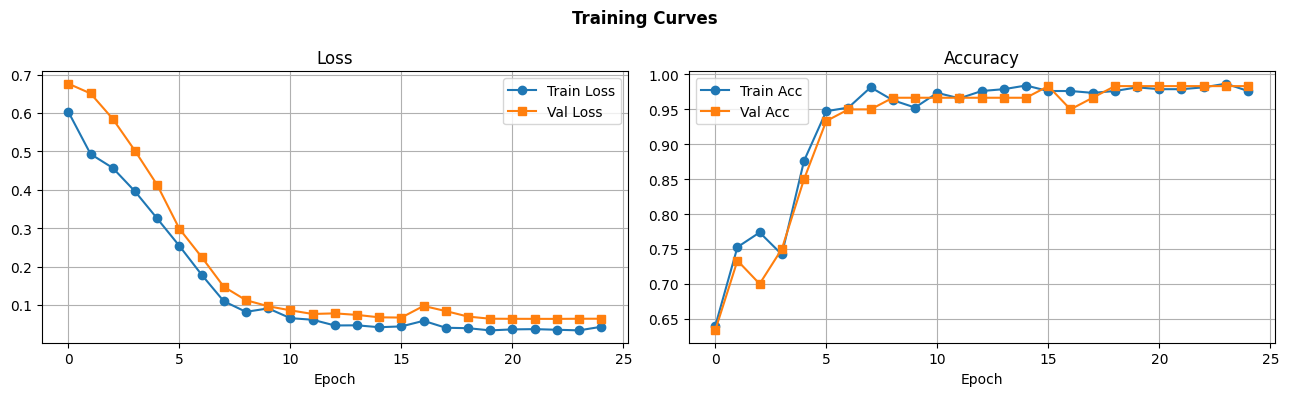

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Training Curves
# ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history["tl"], label="Train Loss", marker="o")
ax1.plot(history["vl"], label="Val Loss",   marker="s")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True)

ax2.plot(history["ta"], label="Train Acc", marker="o")
ax2.plot(history["va"], label="Val Acc",   marker="s")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True)

plt.suptitle("Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150)
plt.show()



Testing: 100%|██████████| 1/1 [00:00<00:00,  1.45it/s]


          TEST SET RESULTS
  Accuracy  : 0.9500
  Precision : 0.9355
  Recall    : 0.9667
  F1-Score  : 0.9508
              precision    recall  f1-score   support

        Real       0.97      0.93      0.95        30
        Fake       0.94      0.97      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



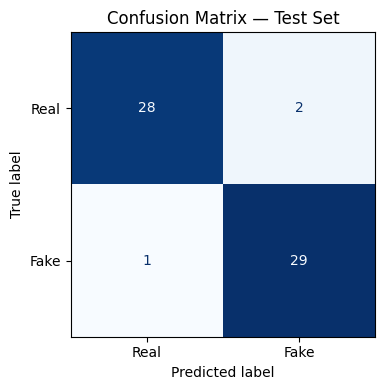

In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Evaluation on Test Set
# ─────────────────────────────────────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        logits = model(imgs.to(DEVICE))
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score(all_labels, all_preds, zero_division=0)
f1   = f1_score(all_labels, all_preds, zero_division=0)
cm   = confusion_matrix(all_labels, all_preds)

print("=" * 44)
print("          TEST SET RESULTS")
print("=" * 44)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 44)
print(classification_report(all_labels, all_preds, target_names=["Real", "Fake"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()


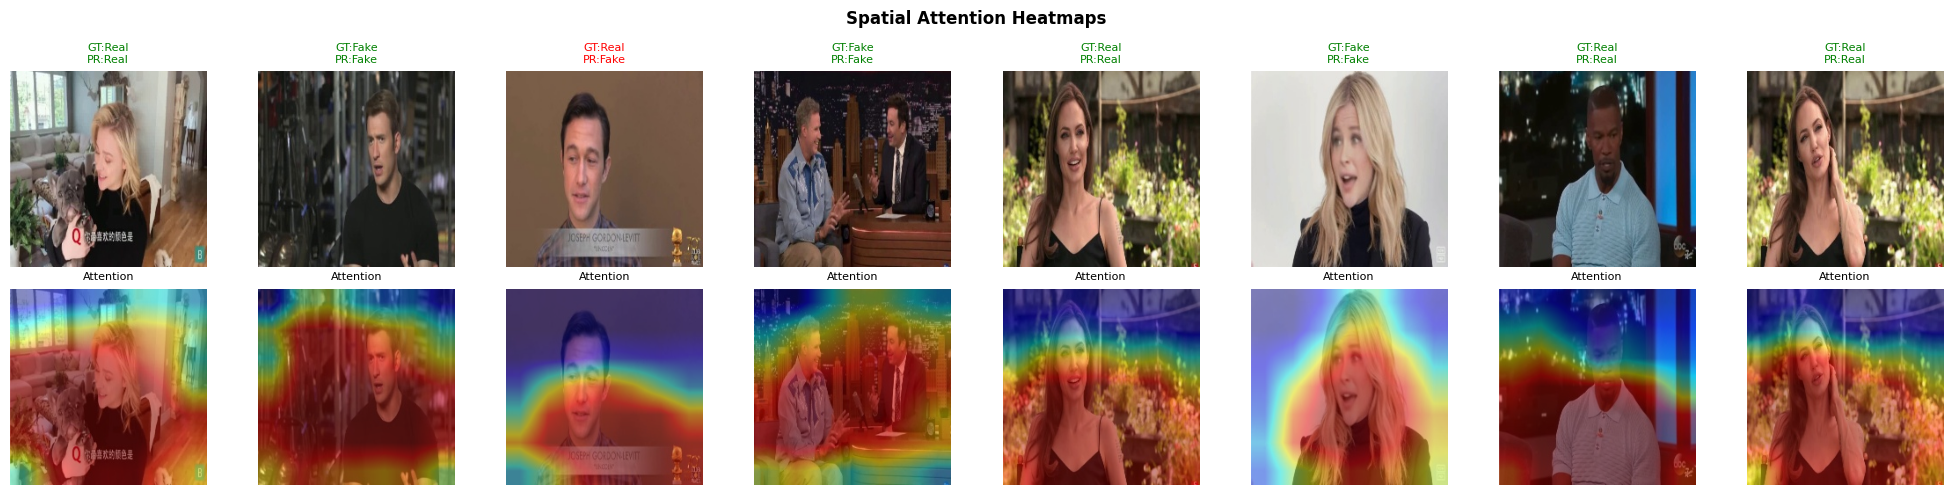

✅  Heatmaps saved.


In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — Attention Heatmap Visualisation (Batch)
# ─────────────────────────────────────────────────────────────
def show_heatmaps(loader, model, n=8):
    model.eval()
    imgs_c, preds_c, labels_c, attn_c = [], [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            logits, attn = model(imgs.to(DEVICE), return_attn=True)
            preds = logits.argmax(1)
            for i in range(imgs.size(0)):
                imgs_c.append(imgs[i])
                preds_c.append(preds[i].item())
                labels_c.append(labels[i].item())
                attn_c.append(attn[i, 0].cpu().numpy())
            if len(imgs_c) >= n:
                break

    mean_t = torch.tensor(MEAN).view(3,1,1)
    std_t  = torch.tensor(STD).view(3,1,1)
    S      = CFG["img_size"]

    fig, axes = plt.subplots(2, n, figsize=(n*2.5, 5))
    for i in range(n):
        img_np = (imgs_c[i] * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()

        # Original
        axes[0,i].imshow(img_np); axes[0,i].axis("off")
        gt  = "Real" if labels_c[i] == 0 else "Fake"
        pr  = "Real" if preds_c[i]  == 0 else "Fake"
        col = "green" if gt == pr else "red"
        axes[0,i].set_title(f"GT:{gt}\nPR:{pr}", fontsize=8, color=col)

        # Heatmap overlay
        am  = cv2.resize(attn_c[i], (S, S))
        am  = (am - am.min()) / (am.max() - am.min() + 1e-8)
        hm  = cv2.applyColorMap((am*255).astype(np.uint8), cv2.COLORMAP_JET)
        hm  = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB) / 255.0
        ov  = np.clip(0.55*img_np + 0.45*hm, 0, 1)
        axes[1,i].imshow(ov); axes[1,i].axis("off")
        axes[1,i].set_title("Attention", fontsize=8)

    axes[0,0].set_ylabel("Image",   fontsize=9)
    axes[1,0].set_ylabel("Heatmap", fontsize=9)
    plt.suptitle("Spatial Attention Heatmaps", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/attention_heatmaps.png", dpi=150)
    plt.show()
    print("✅  Heatmaps saved.")

show_heatmaps(test_loader, model, n=8)


Sample: /content/frames/real/id55_0005_f00000.jpg


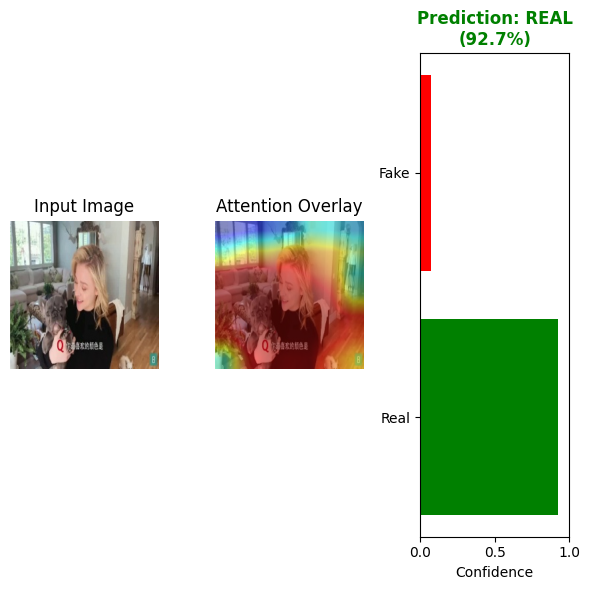


🔍  Prediction : REAL  |  Confidence : 92.72%


('REAL', 0.9272434115409851)

In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 18a — Single-Image Inference
# ─────────────────────────────────────────────────────────────
def predict(img_path):
    """Predict Real/Fake for one image; show original, heatmap, confidence."""
    model.eval()
    img = Image.open(img_path).convert("RGB")
    t   = eval_tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits, attn = model(t, return_attn=True)
        prob  = F.softmax(logits, dim=1)[0]
        pred  = logits.argmax(1).item()

    label = "FAKE" if pred == 1 else "REAL"
    conf  = prob[pred].item()
    S     = CFG["img_size"]

    img_np  = np.array(img.resize((S, S))) / 255.0
    am      = cv2.resize(attn[0, 0].cpu().numpy(), (S, S))
    am      = (am - am.min()) / (am.max() - am.min() + 1e-8)
    hm      = cv2.applyColorMap((am*255).astype(np.uint8), cv2.COLORMAP_JET)
    hm      = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.55*img_np + 0.45*hm, 0, 1)

    fake_conf = conf if label == "FAKE" else 1 - conf
    real_conf = 1 - fake_conf

    fig, axes = plt.subplots(1, 3, figsize=(6, 6))
    axes[0].imshow(img_np);   axes[0].set_title("Input Image");      axes[0].axis("off")
    axes[1].imshow(overlay);  axes[1].set_title("Attention Overlay"); axes[1].axis("off")

    axes[2].barh(["Real", "Fake"], [real_conf, fake_conf], color=["green", "red"])
    axes[2].set_xlim(0, 1); axes[2].set_xlabel("Confidence")
    color = "red" if label == "FAKE" else "green"
    axes[2].set_title(f"Prediction: {label}\n({conf*100:.1f}%)", color=color, fontweight="bold")

    plt.tight_layout()
    plt.savefig("/content/single_prediction.png", dpi=150)
    plt.show()
    print(f"\n🔍  Prediction : {label}  |  Confidence : {conf*100:.2f}%")
    return label, conf


# Run on the first test sample
sample_path = test_df.iloc[0]["path"]
print(f"Sample: {sample_path}")
predict(sample_path)


📂  Click 'Choose Files' to upload an image (jpg / png / bmp)


Saving chakri.jpeg to chakri.jpeg

✅  Uploaded: chakri.jpeg
🔍  Running prediction ...



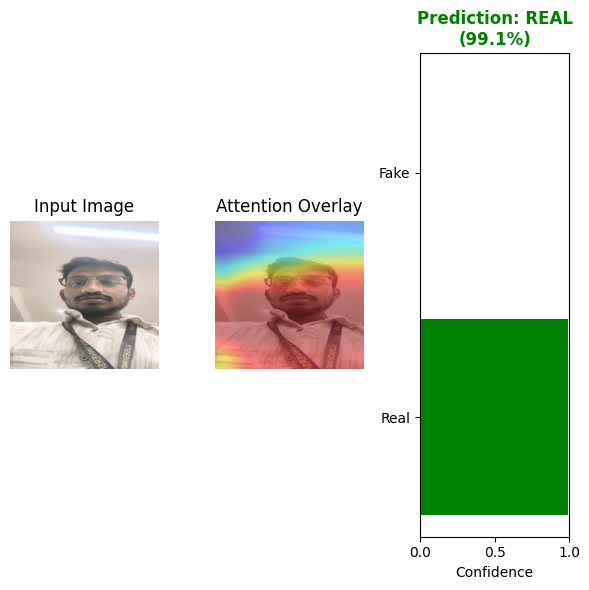


🔍  Prediction : REAL  |  Confidence : 99.10%


In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 18b — Upload Any Image & Run Inference
# ─────────────────────────────────────────────────────────────
from google.colab import files

print("📂  Click 'Choose Files' to upload an image (jpg / png / bmp)")
uploaded = files.upload()   # opens the file picker

if not uploaded:
    print("⚠️  No file uploaded.")
else:
    # Take the first uploaded file
    img_filename = list(uploaded.keys())[0]
    img_path     = f"/content/{img_filename}"

    # Save to /content/ if not already there
    with open(img_path, "wb") as f:
        f.write(uploaded[img_filename])

    print(f"\n✅  Uploaded: {img_filename}")
    print("🔍  Running prediction ...\n")

    # Call the predict() function defined in Cell 18
    label, confidence = predict(img_path)

In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 19 — Cross-Dataset Validation
# ─────────────────────────────────────────────────────────────
def cross_val(name, real_dir, fake_dir, max_n=200):
    real_p = [(str(p), 0) for p in Path(real_dir).glob("*.jpg")][:max_n//2]
    fake_p = [(str(p), 1) for p in Path(fake_dir).glob("*.jpg")][:max_n//2]
    if not (real_p and fake_p):
        print(f"  [{name}] ⚠️  No frames — skipping."); return

    df_cd = pd.DataFrame(real_p + fake_p, columns=["path","label"])
    ld_cd = DataLoader(FaceDataset(df_cd, eval_tf),
                       batch_size=64, shuffle=False, num_workers=NW)
    model.eval()
    p_all, l_all = [], []
    with torch.no_grad():
        for imgs, labels in ld_cd:
            p_all.extend(model(imgs.to(DEVICE)).argmax(1).cpu().tolist())
            l_all.extend(labels.tolist())

    print(f"  [{name}]  Acc: {accuracy_score(l_all,p_all):.4f}  "
          f"F1: {f1_score(l_all,p_all,zero_division=0):.4f}  (n={len(df_cd)})")

print("── Cross-Dataset Validation ──")
cross_val("Celeb-DF", real_out, fake_out, max_n=200)
cross_val("FF++",     real_out, fake_out, max_n=200)

# ─────────────────────────────────────────────────────────────
# CELL 20 — Save Final Checkpoint
# ─────────────────────────────────────────────────────────────
torch.save({
    "model_state" : model.state_dict(),
    "cfg"         : CFG,
    "history"     : history,
    "test_metrics": {"accuracy": acc, "precision": prec,
                     "recall": rec, "f1": f1},
}, "/content/deepfake_detector_final.pth")

print("\n✅  All done! Files saved to /content/")
print("   📦  best_model.pth")
print("   📦  deepfake_detector_final.pth")
print("   🖼️   training_curves.png")
print("   🖼️   confusion_matrix.png")
print("   🖼️   attention_heatmaps.png")
print("   🖼️   single_prediction.png")

── Cross-Dataset Validation ──
  [Celeb-DF]  Acc: 0.9700  F1: 0.9706  (n=200)
  [FF++]  Acc: 0.9700  F1: 0.9706  (n=200)

✅  All done! Files saved to /content/
   📦  best_model.pth
   📦  deepfake_detector_final.pth
   🖼️   training_curves.png
   🖼️   confusion_matrix.png
   🖼️   attention_heatmaps.png
   🖼️   single_prediction.png
